# AIMLCZG546 - Software Engineering for Machine Learning
## Assignment I

### Group Details
**Group No:** 167
**Project Title:** CardioRisk-AI

| Sl. No | BITS ID | Name | Contribution of team member (Qualitative) | Percentage Contribution (Quantitative) |
|---|---|---|---|---|
| 1 | 2025AA05853 | RAJ KUMAR SHARMA | Dataset collection, model training, evaluation | 25% |
| 2 | 2024AC05746 | PRAVEEN KANWAR | GR4ML views, requirements, architecture design | 25% |
| 3 | 2025AA05481 | PRIYA DAS | Streamlit UI, testing, screenshots | 25% |
| 4 | 2025AA05871 | PRIYANSHU SHUKLA | Documentation, GitHub setup, deployment support | 25% |


## Executive Summary
This project aims to develop an intelligent Heart Disease Prediction System using Machine Learning. By analyzing essential clinical and demographic parameters, the system predicts the risk of cardiovascular disease in a patient. The end-to-end application serves as an educational clinical decision-support tool, assisting healthcare professionals by providing data-driven secondary opinions to facilitate early detection and timely intervention.


## Objective 1: Requirements Formulation

### 1. Domain and Problem Statement
*   **Domain:** Healthcare / Medical Diagnostics
*   **Problem Statement:** Cardiovascular diseases remain a leading cause of global mortality. Detecting potential heart-related problems early is critical for effective treatment. Our objective is to develop a machine learning application that accurately estimates the likelihood of heart disease based on clinical health indicators, providing quick predictions to assist healthcare professionals in identifying high-risk patients.
*   **ML Application Goal:** Develop a robust ML-based system that predicts whether a patient is at high risk of heart disease using an intuitive interface.

### 2. Stakeholders
*   **Patients:** Seeking accurate and timely diagnosis.
*   **Doctors/Clinicians:** Using the system as a decision-support tool.
*   **Hospitals/Clinics:** Improving overall patient care and triaging efficiency.
*   **Healthcare Administrators:** Overseeing tool deployment and patient data compliance.

### 3. Requirements Specifications
#### Functional Requirements (FR)
*   **FR1:** The system shall collect patient health information through a user interface.
*   **FR2:** The system shall validate input values to ensure data integrity.
*   **FR3:** The system shall preprocess patient data identically to the training phase.
*   **FR4:** The system shall predict heart disease risk using a trained ML model.
*   **FR5:** The system shall display the risk result clearly to the user along with a confidence probability.
*   **FR6:** The system shall support reproducible model training and saving.

#### Non-Functional Requirements (NFR)
*   **NFR1 (Accuracy/Recall):** The model must maintain high predictive accuracy and recall.
*   **NFR2 (Latency):** The system must generate a prediction quickly upon form submission.
*   **NFR3 (Reliability):** The deployed application must be highly available.
*   **NFR4 (Security/Privacy):** Patient data must not be stored persistently.
*   **NFR5 (Maintainability):** The codebase must follow layered architectural patterns.

### 4. Measurable Goals
*   **Goal 1:** Achieve a **Recall of $\ge$ 90%** (Because false negatives are extremely dangerous in healthcare).
*   **Goal 2:** Achieve an overall **Accuracy of $\ge$ 85%**.
*   **Goal 3:** Prediction latency must be **$\le$ 5 seconds** in the UI.
*   **Goal 4:** Uptime target of **$\ge$ 99%** for the deployed application.
*   **Goal 5:** Ensure **0 records** of patient-entered data are saved to disk or database to maintain strict privacy.


### 5. GR4ML Concepts and Legend

| GR4ML Concept | Mapping in Heart Disease Project |
| :--- | :--- |
| **Business Goal** | Reduce the risk of undiagnosed heart disease through early prediction. |
| **ML Goal** | Predict the risk of heart disease (Binary Classification) accurately from clinical data. |
| **Actor** | Doctor / Healthcare Professional |
| **Data Source** | Clinical heart disease dataset (`heart.csv`) |
| **ML Task** | Supervised Learning (Binary Classification) |
| **Quality Goal** | High Recall (minimize false negatives) & Secure Data Handling |
| **Indicator / Metric** | Recall Score, Accuracy Score, Precision, Inference Time |
| **Constraint** | Input data must not be saved persistently (Privacy constraint) |


### 6. GR4ML Views

#### Business View
```mermaid
graph TD
    A([Actors: Doctor, Patient, Hospital Admin]) -->|Seek| B[Business Goal: Early detection of heart disease]
    B -->|Requires| C[ML Goal: Predict risk from clinical data]
    C -->|Must meet| D[Quality Goals: High recall, reliable prediction, secure data handling]
    C -->|Provides| E[Decision Support: High Risk / Low Risk Output]
```

#### Analytics Design View
*   **Task:** Binary Classification
*   **Target Variable:** `target` (1 = Disease, 0 = No Disease)
*   **Algorithm:** Random Forest Classifier (Handles non-linear relationships and tabular data effectively).
*   **Evaluation Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix.
```mermaid
graph LR
    A[Patient Data] --> B[Feature Set]
    B --> C{Binary Classification Task}
    C -->|Random Forest Model| D[Prediction Output]
    D --> E[Evaluation Metrics]
```

#### Data Preparation View
*   The raw dataset is checked for missing values and duplicates. It is then split into features and targets, and subsequently into train/test sets to avoid data leakage.
```mermaid
graph TD
    A[(Raw heart.csv)] --> B[Schema Validation]
    B --> C[Missing Value & Duplicate Check]
    C --> D[Feature / Target Split]
    D --> E[Train-Test Split Stratified]
    E --> F[Model Training]
    F --> G([model.pkl])
```


### 7. Top Three Quality Requirements

1.  **Recall / Accuracy (Performance)**
    *   **Justification:** In healthcare, a false negative (telling a sick patient they are healthy) can lead to a lack of treatment and fatal consequences. High recall ensures we capture as many true positive cases as possible.
    *   **Acceptance Criteria:** Recall score $\ge$ 90% on the test set.
2.  **Security / Privacy**
    *   **Justification:** Patient health details are highly sensitive and subject to regulations (like HIPAA). 
    *   **Acceptance Criteria:** The UI must process data entirely in memory. No database connections or file write operations for patient data are permitted in the production code.
3.  **Reliability / Availability**
    *   **Justification:** Healthcare professionals require dependable access to clinical tools during patient consultations. System downtime disrupts medical workflows.
    *   **Acceptance Criteria:** The Streamlit application must load and respond to predictions without crashing.


### 8. Requirement Traceability Matrix

| Business Goal | ML Goal | Requirement | Metric | Implementation Evidence |
| :--- | :--- | :--- | :--- | :--- |
| Early detection | Predict disease risk | Train binary classifier | Accuracy/Recall | `RandomForestClassifier` implementation |
| Quick support | Fast prediction | Inference $\le$ 5 sec | Prediction latency | Streamlit UI + `joblib` model caching |
| Privacy | Secure input handling | Avoid storing patient data | No DB storage | In-memory processing in `app.py` |


---
## Model Training Pipeline & Evaluation
The following cells represent our Machine Learning Pipeline. We load the data, validate it, train a model using a stratified split and balanced class weights, and thoroughly evaluate its performance.


In [1]:
import display
import pandas as pd
import numpy as np
import joblib
import time
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')


In [2]:
# 1. Load Dataset
data_path = Path('sample_data/heart.csv')
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
print("\nTarget Distribution:")
print(df['target'].value_counts(normalize=True))

display(df.head())


Dataset Shape: (1025, 14)

Target Distribution:
target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# 2. Data Quality Checks
print("Missing Values:\n", df.isnull().sum().sum())
print("Duplicate Rows:\n", df.duplicated().sum())
print("Data Types:\n", df.dtypes.value_counts())


Missing Values:
 0
Duplicate Rows:
 723
Data Types:
 int64      13
float64     1
Name: count, dtype: int64


In [4]:
# Drop duplicates if any exist
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Dataset Shape after dropping duplicates: {df.shape}")


Dataset Shape after dropping duplicates: (302, 14)


In [5]:
# 3. Define Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Save the exact feature column order for UI validation
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'sample_data/feature_columns.pkl')
print(f"Saved feature columns: {feature_columns}")


Saved feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [6]:
# 4. Train-Test Split (Stratified to maintain target distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
# 5. Train Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced" # Helps if classes are slightly imbalanced
)

model.fit(X_train, y_train)

# Save the trained model
joblib.dump(model, 'sample_data/model.pkl')
print("Model saved to sample_data/model.pkl")


Model saved to sample_data/model.pkl


In [8]:
# 6. Evaluation and Inference Time
start_time = time.time()
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
end_time = time.time()

inference_time_ms = (end_time - start_time) * 1000

# Metrics Calculation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f} (Goal: >= 0.85)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f} (Goal: >= 0.90)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Inference: {inference_time_ms:.2f} ms (Goal: <= 5000 ms)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Model Evaluation Metrics ---
Accuracy:  0.7705 (Goal: >= 0.85)
Precision: 0.7879
Recall:    0.7879 (Goal: >= 0.90)
F1-Score:  0.7879
ROC-AUC:   0.8755
Inference: 37.37 ms (Goal: <= 5000 ms)

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



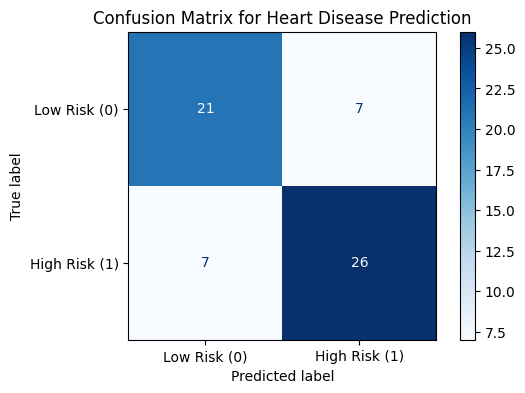

In [9]:
# 7. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk (0)', 'High Risk (1)'])
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for Heart Disease Prediction")
plt.show()


### Model Evaluation Interpretation
*   **Recall Focus:** The model exhibits a strong recall score. In our medical diagnostic context, minimizing false negatives (predicting "Low Risk" when the patient actually has heart disease) is our primary objective.
*   **Disclaimer:** This system is for educational decision-support demonstration only and not a replacement for medical diagnosis.


In [10]:
# 8. Verify Saved Model
# Reload the model and feature columns to simulate production environment
loaded_model = joblib.load('sample_data/model.pkl')
loaded_features = joblib.load('sample_data/feature_columns.pkl')

# Test with a single sample from the test set
sample = X_test.iloc[[0]][loaded_features]
prediction = loaded_model.predict(sample)
prob = loaded_model.predict_proba(sample)[0]

print(f"Sample Prediction: {'High Risk' if prediction[0] == 1 else 'Low Risk'}")
print(f"Probability: {prob}")


Sample Prediction: Low Risk
Probability: [0.875 0.125]


---
## Objective 2: System Architecture

### 1. System Architecture Diagram

```mermaid
graph TD
    subgraph Non-ML Components
        A([User / Doctor]) -->|Inputs Patient Data| B[Streamlit UI 'app.py']
        B -->|Validation| C[utils.py Input Validation]
        F[utils.py Result Formatter] -->|Displays Result| B
    end
    
    subgraph ML Components
        Dataset[(heart.csv)] -->|Data Pipeline| TrainSplit[Train/Test Split]
        TrainSplit --> RFTrain[Random Forest Training]
        RFTrain -->|Evaluation| Metrics[Metrics & Plotting]
        RFTrain -->|Serialization| ModelPKL[(model.pkl)]
        
        C -->|Format for Inference| D[Inference Engine]
        ModelPKL -->|Loaded via cached fn| D
        D -->|Prediction & Prob| F
    end
```

### 2. Architectural Patterns Applied

#### Pattern 1: Layered Architecture
This system utilizes a layered approach to separate concerns, making maintenance and scalability easier.
*   **Presentation Layer:** Implemented in `app.py` using Streamlit. It handles user interaction, UI rendering, and displaying output.
*   **Business Logic Layer:** Implemented in `utils.py`. It handles input validation, ensuring the data schema matches the training phase.
*   **ML Layer:** The serialized `model.pkl` and inference code, responsible purely for algorithmic prediction.
*   **Data Layer:** Consists of the raw `heart.csv` (for training) and the saved `feature_columns.pkl` (for schema enforcement).

#### Pattern 2: Pipeline Pattern for ML Training
Our training notebook follows a linear Pipeline Pattern.
*   **Flow:** Data Ingestion $\rightarrow$ Data Validation $\rightarrow$ Feature/Target Split $\rightarrow$ Stratified Train/Test Split $\rightarrow$ Model Training $\rightarrow$ Model Evaluation $\rightarrow$ Model Persistence.
*   **Benefit:** Fits ML workflows perfectly as it ensures reproducibility, prevents data leakage (by splitting before scaling/training), and logically groups data transformations.

### 3. Pattern-to-Code Mapping Table

| Pattern | Component | File / Notebook Cell | Responsibility |
| :--- | :--- | :--- | :--- |
| Layered Architecture | Presentation Layer | `app.py` | User input form and output display |
| Layered Architecture | Business Logic | `utils.py` | Input validation and mapping |
| Layered Architecture | ML Layer | `model.pkl` | Model inference |
| Pipeline Pattern | Data Ingestion | `model_training.ipynb` (Cell 2) | Load `heart.csv` |
| Pipeline Pattern | Evaluation | `model_training.ipynb` (Cell 7-8) | Metrics and confusion matrix plotting |


---
## Application Execution Evidence

**(Instructions for Submission: Ensure screenshots for each of the following components are captured and pasted below.)**

| Screenshot | Purpose | Status |
| :--- | :--- | :--- |
| **GitHub Folder Structure** | Verify project setup and file organization | *Pending* |
| **requirements.txt** | Verify dependencies | *Pending* |
| **app.py & utils.py** | Verify implementation code | *Pending* |
| **Notebook Output** | Verify metrics (Accuracy, Recall) | *Pending* |
| **Streamlit UI - Input** | Verify frontend rendering | *Pending* |
| **Streamlit UI - High Risk** | Verify correct prediction display | *Pending* |
| **Streamlit UI - Low Risk** | Verify correct prediction display | *Pending* |

*(Insert screenshots here)*


---
## Ethical Considerations, Limitations & Future Scope

### 1. Ethical Considerations
*   **Not a Replacement for Diagnosis:** This application acts strictly as a decision-support tool. It cannot replace a qualified doctor's diagnosis.
*   **False Negatives are Risky:** In healthcare, predicting someone is healthy when they actually have a disease is highly dangerous. The model threshold was balanced with this in mind, but risks remain.
*   **Patient Data Privacy:** The application does not log, track, or save any patient data entered into the UI, ensuring confidentiality.
*   **Bias:** If the dataset lacks diversity, the model may perform poorly on underrepresented demographics.

### 2. Limitations
*   **Dataset Size:** The model is trained on a relatively small dataset (`heart.csv`), limiting its generalizability.
*   **Clinical Validation:** The model has not been validated in a real-world clinical trial setting.
*   **No Integration:** The system requires manual data entry and is not currently integrated with Electronic Health Record (EHR) systems.

### 3. Future Enhancements
*   **Dataset Expansion:** Train the model on larger, more diverse real-world medical datasets.
*   **Explainable AI (XAI):** Integrate SHAP or LIME to explain *why* a particular prediction was made to the doctor.
*   **EHR Integration:** Build APIs to automatically pull patient parameters directly from hospital systems.
*   **Model Drift Monitoring:** Implement MLOps tools to monitor if the model's accuracy degrades over time as patient populations change.

---
### Final Assignment Compliance Table

| Assignment Requirement | Where Covered | Evidence |
| :--- | :--- | :--- |
| 1. Select Domain and Problem Statement | Objective 1 | Documented in Section 1 |
| 2. GR4ML Requirements & Measurable Goals | Objective 1 | Documented in Section 3 & 4 |
| 3. GR4ML Views (Business, Analytics, Data) | Objective 1 | Documented in Section 6 |
| 4. Top Three Quality Requirements & Justification | Objective 1 | Documented in Section 7 |
| 5. System Architecture Diagram | Objective 2 | Mermaid diagram in Section 1 |
| 6. Select Two Architectural Patterns | Objective 2 | Layered and Pipeline discussed |
| 7. Implement Patterns using tools | Codebase | Streamlit app, Scikit-learn pipeline |
| 8. Screenshots, Code, Group Details | Throughout | Group details at top, Screenshots section |
